# Person 3 — Temporal CNN Audio Classification

**Owner: Prince Mbonyumugisha**

## Temporal CNN Architecture

This model uses a temporal CNN to classify 12 Swahili words from
ordered MFCC frame sequences.

Two one-dimensional convolutional layers learn local patterns
across neighbouring audio frames. With kernel size five and
stride one, the two layers have a receptive field of nine frames.

Padding is masked after each convolution. Mean pooling uses
only valid frames, followed by a linear classification head.

Its local receptive field does not explicitly model long-range
frame relationships.


In [23]:
from pathlib import Path
import sys
import zipfile

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError("Cannot find the project folder containing src.")
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.loading import audio_zip_path, load_train_csv, read_shared_split
from src.preprocessing.config import PreprocessingConfig
from src.preprocessing.sequences import (
    extract_static_sequences,
    fit_frame_standardizer,
    standardize,
)
from src.utils.reproducibility import SHARED_SPLIT_SEED, set_seed

set_seed(SHARED_SPLIT_SEED)
labels = load_train_csv()
split = read_shared_split()
data = labels.merge(split, on="Word_id", how="inner", validate="one_to_one")

with zipfile.ZipFile(audio_zip_path()) as archive:
    audio_members = set(archive.namelist())
missing_audio = sorted(set(data["Word_id"]) - audio_members)
assert not missing_audio, f"Audio files missing from ZIP: {missing_audio[:5]}"

class_names = sorted(data.loc[data["split"] == "train", "Swahili_word"].unique())
label_to_index = {name: index for index, name in enumerate(class_names)}
data["target"] = data["Swahili_word"].map(label_to_index)
assert data["target"].notna().all(), "A class is absent from training."

preprocessing = PreprocessingConfig()
train_rows = data.loc[data["split"] == "train"].reset_index(drop=True)
cache_dir = ROOT / "data" / "processed" / "person3"
train_static = extract_static_sequences(
    train_rows["Word_id"].tolist(),
    preprocessing,
    cache_path=cache_dir / "train_static.npz",
)
feature_mean, feature_std = fit_frame_standardizer(train_static)
train_sequences = standardize(train_static, feature_mean, feature_std)

print("Project:", ROOT)
print("Training sequences:", len(train_sequences))
print("Classes:", class_names)
print("Shared split remains unchanged.")

Project: /Users/Prince/NLP-and-Language-Technologies
Training sequences: 2940
Classes: ['hapana', 'kumi', 'mbili', 'moja', 'nane', 'ndio', 'nne', 'saba', 'sita', 'tano', 'tatu', 'tisa']
Shared split remains unchanged.


In [24]:
import torch
from torch.nn.utils.rnn import pad_sequence
from src.models.temporal_cnn import TemporalCNNClassifier

torch.manual_seed(SHARED_SPLIT_SEED)

model = TemporalCNNClassifier(
    n_features=train_sequences[0].shape[1],
    n_classes=len(class_names),
)

examples = [
    torch.from_numpy(sequence)
    for sequence in train_sequences[:4]
]
lengths = torch.tensor([len(x) for x in examples])
batch = pad_sequence(examples, batch_first=True)

model.eval()
with torch.no_grad():
    logits = model(batch, lengths)

    extra = torch.zeros(batch.shape[0], 20, batch.shape[2])
    padded_logits = model(
        torch.cat([batch, extra], dim=1), lengths
    )

assert logits.shape == (4, len(class_names))
assert torch.isfinite(logits).all()
assert torch.allclose(logits, padded_logits, atol=1e-6)

print("Input shape:", tuple(batch.shape))
print("Output shape:", tuple(logits.shape))
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("CNN check passed, including padding invariance.")

Input shape: (4, 358, 13)
Output shape: (4, 12)
Parameters: 25548
CNN check passed, including padding invariance.


## Validation Data Preparation

**Owner: Prince Mbonyumugisha — Person 3**

We prepare the 630 validation recordings using the existing shared
split and the same MFCC configuration used for training.

Validation features are standardized using the mean and standard
deviation fitted on training frames only. Word labels are converted
to integer indices using the training class mapping.

The validation set will guide hyperparameter tuning and early
stopping based on macro-F1. The test set is not used in this step,
and the shared split remains unchanged.

In [25]:
# Check which preparation variables are already available.
required = [
    "data", "preprocessing", "train_sequences",
    "feature_mean", "feature_std", "y_train",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing preparation variables: {missing}. "
        "Share your current data preparation cell."
    )

import numpy as np
from src.preprocessing.sequences import (
    extract_static_sequences,
    standardize,
)

val_rows = data.loc[
    data["split"] == "validation"
].reset_index(drop=True)

val_static = extract_static_sequences(
    val_rows["Word_id"].tolist(),
    preprocessing,
    cache_path=(
        ROOT / "data" / "processed" / "person3_cnn"
        / "validation_static.npz"
    ),
)

# Reuse training statistics—do not fit on validation data.
val_sequences = standardize(
    val_static, feature_mean, feature_std
)

label_to_index = {
    word: index for index, word in enumerate(class_names)
}
val_targets = val_rows["Swahili_word"].map(label_to_index)
assert val_targets.notna().all()
y_val = val_targets.to_numpy(dtype=np.int64)

assert len(train_sequences) == len(y_train)
assert len(val_sequences) == len(y_val) == 630

print("Training sequences:", len(train_sequences))
print("Validation sequences:", len(val_sequences))
print("MFCC features per frame:", val_sequences[0].shape[1])
print("Ready for CNN training. Test data not used.")

MFCC sequences 250/630
MFCC sequences 500/630
Training sequences: 2940
Validation sequences: 630
MFCC features per frame: 13
Ready for CNN training. Test data not used.


## CNN Training

We train the temporal CNN using cross-entropy loss and AdamW.
Initial settings are learning rate 0.001, weight decay 0.0001,
batch size 32, dropout 0.2, and a maximum of 30 epochs.

Early stopping monitors validation macro-F1 with patience five.
The best validation checkpoint is restored and saved with the
preprocessing settings, training normalization statistics, and
class mapping.

These are initial experimental settings. Test data is not used
for training or model selection.

In [26]:
import copy
import time
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence

from src.models.temporal_cnn import TemporalCNNClassifier
from src.evaluation.metrics import classification_metrics

set_seed(SHARED_SPLIT_SEED)
torch.manual_seed(SHARED_SPLIT_SEED)

device = torch.device("cpu")
model_config = {
    "n_features": train_sequences[0].shape[1],
    "n_classes": len(class_names),
    "channels": 64,
    "kernel_size": 5,
    "dropout": 0.2,
}
model = TemporalCNNClassifier(**model_config).to(device)

batch_size = 32
max_epochs = 30
patience = 5

# Prevent accidental overwriting of a completed experiment.
results_dir = ROOT / "results" / "person3_cnn"
results_dir.mkdir(parents=True, exist_ok=True)
if (results_dir / "best_model.pt").exists():
    raise FileExistsError(
        "CNN checkpoint already exists. Use a new results folder."
    )

optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)
loss_fn = nn.CrossEntropyLoss()
rng = np.random.default_rng(SHARED_SPLIT_SEED)


def cnn_batch(sequences, targets, indices):
    tensors = [
        torch.from_numpy(sequences[int(i)])
        for i in indices
    ]
    lengths = torch.tensor(
        [len(x) for x in tensors], dtype=torch.long
    )
    x = pad_sequence(tensors, batch_first=True).to(device)
    y = torch.as_tensor(
        targets[indices], dtype=torch.long, device=device
    )
    return x, lengths, y


@torch.no_grad()
def cnn_evaluate(model, sequences, targets):
    model.eval()
    probabilities = []
    total_loss = 0.0

    for start in range(0, len(sequences), batch_size):
        indices = np.arange(
            start, min(start + batch_size, len(sequences))
        )
        x, lengths, y = cnn_batch(sequences, targets, indices)
        logits = model(x, lengths)
        total_loss += loss_fn(logits, y).item() * len(indices)
        probabilities.append(logits.softmax(dim=1).cpu().numpy())

    proba = np.concatenate(probabilities)
    metrics = classification_metrics(
        targets, proba.argmax(axis=1)
    )
    return total_loss / len(sequences), metrics, proba


best_f1 = -1.0
best_epoch = 0
best_state = None
history_rows = []
training_start = time.perf_counter()

for epoch in range(1, max_epochs + 1):
    epoch_start = time.perf_counter()
    model.train()
    order = rng.permutation(len(train_sequences))
    total_loss = 0.0
    correct = 0

    for start in range(0, len(order), batch_size):
        indices = order[start:start + batch_size]
        x, lengths, y = cnn_batch(
            train_sequences, y_train, indices
        )

        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = loss_fn(logits, y)

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss.")

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * len(indices)
        correct += (logits.argmax(dim=1) == y).sum().item()

    val_loss, val_metrics, _ = cnn_evaluate(
        model, val_sequences, y_val
    )

    history_rows.append({
        "epoch": epoch,
        "train_loss": total_loss / len(train_sequences),
        "train_accuracy": correct / len(train_sequences),
        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "seconds": time.perf_counter() - epoch_start,
    })

    if val_metrics["macro_f1"] > best_f1:
        best_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    row = history_rows[-1]
    print(
        f"Epoch {epoch:02d} | "
        f"train loss {row['train_loss']:.4f} | "
        f"val loss {val_loss:.4f} | "
        f"val macro-F1 {val_metrics['macro_f1']:.4f} | "
        f"{row['seconds']:.1f}s",
        flush=True,
    )

    if epoch - best_epoch >= patience:
        print("Early stopping.")
        break

model.load_state_dict(best_state)
model.eval()
history = pd.DataFrame(history_rows)
training_seconds = time.perf_counter() - training_start

history.to_csv(results_dir / "training_history.csv", index=False)

torch.save({
    "model_state_dict": model.state_dict(),
    "model_config": model_config,
    "class_names": list(class_names),
    "feature_mean": torch.from_numpy(feature_mean),
    "feature_std": torch.from_numpy(feature_std),
    "preprocessing": preprocessing.to_dict(),
    "seed": SHARED_SPLIT_SEED,
    "best_epoch": best_epoch,
    "best_validation_macro_f1": best_f1,
    "training_seconds": training_seconds,
    "training_config": {
        "batch_size": batch_size,
        "max_epochs": max_epochs,
        "patience": patience,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "grad_clip": 1.0,
    },
}, results_dir / "best_model.pt")

print("\nBest epoch:", best_epoch)
print("Best validation macro-F1:", round(best_f1, 4))
print("Training seconds:", round(training_seconds, 1))
print("Saved results:", results_dir)

Epoch 01 | train loss 2.4633 | val loss 2.3816 | val macro-F1 0.1366 | 16.3s
Epoch 02 | train loss 2.3321 | val loss 2.2201 | val macro-F1 0.2161 | 13.2s
Epoch 03 | train loss 2.1804 | val loss 2.0824 | val macro-F1 0.2858 | 12.8s
Epoch 04 | train loss 2.0511 | val loss 1.9816 | val macro-F1 0.3283 | 13.0s
Epoch 05 | train loss 1.9458 | val loss 1.8616 | val macro-F1 0.4029 | 12.9s
Epoch 06 | train loss 1.8441 | val loss 1.7890 | val macro-F1 0.4239 | 12.9s
Epoch 07 | train loss 1.7542 | val loss 1.6948 | val macro-F1 0.4180 | 12.8s
Epoch 08 | train loss 1.6916 | val loss 1.6306 | val macro-F1 0.4674 | 12.7s
Epoch 09 | train loss 1.6193 | val loss 1.5677 | val macro-F1 0.4707 | 12.9s
Epoch 10 | train loss 1.5723 | val loss 1.5378 | val macro-F1 0.5113 | 12.9s
Epoch 11 | train loss 1.5202 | val loss 1.4764 | val macro-F1 0.5088 | 13.6s
Epoch 12 | train loss 1.4778 | val loss 1.4395 | val macro-F1 0.5434 | 12.8s
Epoch 13 | train loss 1.4228 | val loss 1.4078 | val macro-F1 0.5465 | 12.9s

## Training Budget Experiment

The initial CNN achieved its best validation macro-F1 of 0.6986
at epoch 30, the maximum permitted epoch. Validation loss was
still decreasing, and early stopping had not triggered.

We therefore increase the maximum training budget from 30 to
60 epochs, keeping all other settings unchanged. The model is
trained from scratch with seed 42, using validation macro-F1
for checkpoint selection and early stopping.

This experiment tests whether the initial training budget limited
performance. Test data is not used.

In [27]:
import copy
import time
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence

from src.models.temporal_cnn import TemporalCNNClassifier
from src.evaluation.metrics import classification_metrics

# Same seed and architecture as the 30-epoch experiment.
set_seed(SHARED_SPLIT_SEED)
torch.manual_seed(SHARED_SPLIT_SEED)

device = torch.device("cpu")
model_config = {
    "n_features": train_sequences[0].shape[1],
    "n_classes": len(class_names),
    "channels": 64,
    "kernel_size": 5,
    "dropout": 0.2,
}

batch_size = 32
max_epochs = 60
patience = 5

results_dir = ROOT / "results" / "person3_cnn_60epochs"
results_dir.mkdir(parents=True, exist_ok=True)

if (results_dir / "best_model.pt").exists():
    raise FileExistsError(
        "This experiment already has a checkpoint. "
        "Use a new folder rather than overwriting it."
    )

# Train from scratch; do not load the previous checkpoint.
model = TemporalCNNClassifier(**model_config).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)
loss_fn = nn.CrossEntropyLoss()
rng = np.random.default_rng(SHARED_SPLIT_SEED)


def cnn_batch(sequences, targets, indices):
    tensors = [
        torch.from_numpy(sequences[int(i)])
        for i in indices
    ]
    lengths = torch.tensor(
        [len(x) for x in tensors], dtype=torch.long
    )
    x = pad_sequence(tensors, batch_first=True).to(device)
    y = torch.as_tensor(
        targets[indices], dtype=torch.long, device=device
    )
    return x, lengths, y


@torch.no_grad()
def cnn_evaluate(model, sequences, targets):
    model.eval()
    probabilities = []
    total_loss = 0.0

    for start in range(0, len(sequences), batch_size):
        indices = np.arange(
            start, min(start + batch_size, len(sequences))
        )
        x, lengths, y = cnn_batch(sequences, targets, indices)
        logits = model(x, lengths)
        total_loss += loss_fn(logits, y).item() * len(indices)
        probabilities.append(
            logits.softmax(dim=1).cpu().numpy()
        )

    proba = np.concatenate(probabilities)
    metrics = classification_metrics(
        targets, proba.argmax(axis=1)
    )
    return total_loss / len(sequences), metrics, proba


best_f1 = -1.0
best_epoch = 0
best_state = None
history_rows = []
training_start = time.perf_counter()

for epoch in range(1, max_epochs + 1):
    epoch_start = time.perf_counter()
    model.train()
    order = rng.permutation(len(train_sequences))
    total_loss = 0.0
    correct = 0

    for start in range(0, len(order), batch_size):
        indices = order[start:start + batch_size]
        x, lengths, y = cnn_batch(
            train_sequences, y_train, indices
        )

        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = loss_fn(logits, y)

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss.")

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * len(indices)
        correct += (logits.argmax(dim=1) == y).sum().item()

    val_loss, val_metrics, _ = cnn_evaluate(
        model, val_sequences, y_val
    )

    history_rows.append({
        "epoch": epoch,
        "train_loss": total_loss / len(train_sequences),
        "train_accuracy": correct / len(train_sequences),
        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "seconds": time.perf_counter() - epoch_start,
    })

    if val_metrics["macro_f1"] > best_f1:
        best_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    row = history_rows[-1]
    print(
        f"Epoch {epoch:02d} | "
        f"train loss {row['train_loss']:.4f} | "
        f"val loss {val_loss:.4f} | "
        f"val macro-F1 {val_metrics['macro_f1']:.4f} | "
        f"{row['seconds']:.1f}s",
        flush=True,
    )

    if epoch - best_epoch >= patience:
        print("Early stopping.")
        break

# Restore and save the best validation checkpoint.
model.load_state_dict(best_state)
model.eval()

history = pd.DataFrame(history_rows)
training_seconds = time.perf_counter() - training_start
history.to_csv(
    results_dir / "training_history.csv", index=False
)

torch.save({
    "model_state_dict": model.state_dict(),
    "model_config": model_config,
    "class_names": list(class_names),
    "feature_mean": torch.from_numpy(feature_mean),
    "feature_std": torch.from_numpy(feature_std),
    "preprocessing": preprocessing.to_dict(),
    "seed": SHARED_SPLIT_SEED,
    "best_epoch": best_epoch,
    "best_validation_macro_f1": best_f1,
    "training_seconds": training_seconds,
    "training_config": {
        "batch_size": batch_size,
        "max_epochs": max_epochs,
        "patience": patience,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "grad_clip": 1.0,
    },
}, results_dir / "best_model.pt")

print("\nBest epoch:", best_epoch)
print("Best validation macro-F1:", round(best_f1, 4))
print("Training seconds:", round(training_seconds, 1))
print("Saved results:", results_dir)

Epoch 01 | train loss 2.4633 | val loss 2.3816 | val macro-F1 0.1366 | 13.7s
Epoch 02 | train loss 2.3321 | val loss 2.2201 | val macro-F1 0.2161 | 13.1s
Epoch 03 | train loss 2.1804 | val loss 2.0824 | val macro-F1 0.2858 | 12.9s
Epoch 04 | train loss 2.0511 | val loss 1.9816 | val macro-F1 0.3283 | 12.7s
Epoch 05 | train loss 1.9458 | val loss 1.8616 | val macro-F1 0.4029 | 13.1s
Epoch 06 | train loss 1.8441 | val loss 1.7890 | val macro-F1 0.4239 | 12.9s
Epoch 07 | train loss 1.7542 | val loss 1.6948 | val macro-F1 0.4180 | 12.7s
Epoch 08 | train loss 1.6916 | val loss 1.6306 | val macro-F1 0.4674 | 12.7s
Epoch 09 | train loss 1.6193 | val loss 1.5677 | val macro-F1 0.4707 | 12.8s
Epoch 10 | train loss 1.5723 | val loss 1.5378 | val macro-F1 0.5113 | 13.2s
Epoch 11 | train loss 1.5202 | val loss 1.4764 | val macro-F1 0.5088 | 12.7s
Epoch 12 | train loss 1.4778 | val loss 1.4395 | val macro-F1 0.5434 | 12.9s
Epoch 13 | train loss 1.4228 | val loss 1.4078 | val macro-F1 0.5465 | 12.4s

In [28]:
import torch

path = ROOT / "results" / "person3_cnn_60epochs" / "best_model.pt"

if path.exists():
    checkpoint = torch.load(
        path, map_location="cpu", weights_only=True
    )
    print("Best epoch:", checkpoint["best_epoch"])
    print("Best validation macro-F1:",
          checkpoint["best_validation_macro_f1"])
    print("Training seconds:", checkpoint["training_seconds"])
else:
    print("No completed checkpoint found yet.")

Best epoch: 59
Best validation macro-F1: 0.8094034259822639
Training seconds: 776.8696646669996


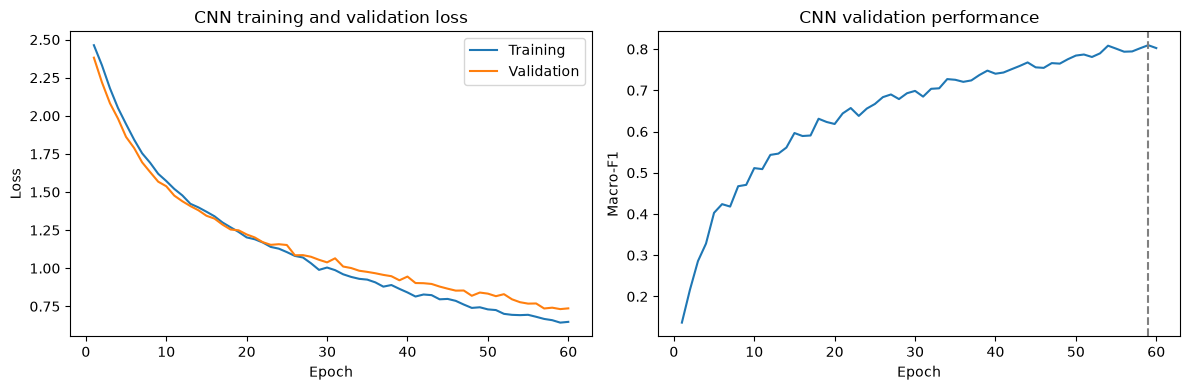

Validation metrics:
accuracy: 0.8095
macro_f1: 0.8094
weighted_f1: 0.8090
macro_precision: 0.8154
macro_recall: 0.8099


,model,stage,class,precision,recall,f1-score,support
0,temporal_cnn,validation,hapana,0.787234,0.698113,0.740000,53.0
1,temporal_cnn,validation,kumi,0.867925,0.884615,0.876190,52.0
2,temporal_cnn,validation,mbili,0.821429,0.867925,0.844037,53.0
3,temporal_cnn,validation,moja,0.857143,0.923077,0.888889,52.0
4,temporal_cnn,validation,nane,0.807018,0.884615,0.844037,52.0
5,temporal_cnn,validation,ndio,0.829787,0.735849,0.780000,53.0
6,temporal_cnn,validation,nne,0.930233,0.769231,0.842105,52.0
7,temporal_cnn,validation,saba,0.867925,0.884615,0.876190,52.0
8,temporal_cnn,validation,sita,0.750000,0.792453,0.770642,53.0
9,temporal_cnn,validation,tano,0.782609,0.679245,0.727273,53.0


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from src.evaluation.metrics import classification_report_frame

selected_dir = ROOT / "results" / "person3_cnn_60epochs"
checkpoint = torch.load(
    selected_dir / "best_model.pt",
    map_location="cpu",
    weights_only=True,
)

model = TemporalCNNClassifier(
    **checkpoint["model_config"]
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

history = pd.read_csv(selected_dir / "training_history.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="Training")
axes[0].plot(history["epoch"], history["val_loss"], label="Validation")
axes[0].set(
    xlabel="Epoch", ylabel="Loss",
    title="CNN training and validation loss"
)
axes[0].legend()

axes[1].plot(history["epoch"], history["val_macro_f1"])
axes[1].axvline(
    checkpoint["best_epoch"], color="gray", linestyle="--"
)
axes[1].set(
    xlabel="Epoch", ylabel="Macro-F1",
    title="CNN validation performance"
)

fig.tight_layout()
fig.savefig(selected_dir / "learning_curves.png", dpi=150)
plt.show()

val_loss, val_metrics, val_proba = cnn_evaluate(
    model, val_sequences, y_val
)
val_predictions = val_proba.argmax(axis=1)

print("Validation metrics:")
for name, value in val_metrics.items():
    print(f"{name}: {value:.4f}")

val_report = classification_report_frame(
    y_val, val_predictions, checkpoint["class_names"],
    model="temporal_cnn", stage="validation",
)
val_report.to_csv(
    selected_dir / "validation_classification_report.csv",
    index=False,
)
display(val_report)

## Final CNN Test Evaluation

The 60-epoch experiment was selected using validation macro-F1.
Its best checkpoint was epoch 59, with validation macro-F1 0.8094.

We evaluate this fixed checkpoint on the 630 recordings assigned
to the shared test split, using its saved preprocessing settings,
training normalization statistics, and class mapping.

This test split was previously inspected during the archived
Transformer experiment. CNN checkpoint selection used validation
results only. The official unlabeled Test.csv is not used.

In [30]:
from src.preprocessing.config import PreprocessingConfig
from src.preprocessing.sequences import (
    extract_static_sequences,
    standardize,
)
from src.evaluation.metrics import (
    classification_metrics,
    classification_report_frame,
    confusion_frame,
)

selected_dir = ROOT / "results" / "person3_cnn_60epochs"
checkpoint = torch.load(
    selected_dir / "best_model.pt",
    map_location="cpu",
    weights_only=True,
)

device = torch.device("cpu")
model = TemporalCNNClassifier(
    **checkpoint["model_config"]
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

selected_classes = checkpoint["class_names"]
mapping = {
    word: index for index, word in enumerate(selected_classes)
}

test_rows = data.loc[
    data["split"] == "test"
].reset_index(drop=True)

test_static = extract_static_sequences(
    test_rows["Word_id"].tolist(),
    PreprocessingConfig(**checkpoint["preprocessing"]),
    cache_path=(
        ROOT / "data" / "processed" / "person3_cnn"
        / "test_static.npz"
    ),
)

test_sequences = standardize(
    test_static,
    checkpoint["feature_mean"].cpu().numpy(),
    checkpoint["feature_std"].cpu().numpy(),
)

targets = test_rows["Swahili_word"].map(mapping)
assert targets.notna().all()
y_test = targets.to_numpy(dtype=np.int64)

# Use the selected checkpoint's evaluation batch size.
batch_size = checkpoint["training_config"]["batch_size"]
_, _, test_proba = cnn_evaluate(model, test_sequences, y_test)
test_predictions = test_proba.argmax(axis=1)

test_metrics = classification_metrics(
    y_test, test_predictions, proba=test_proba
)
pd.DataFrame([{
    "model": "temporal_cnn",
    "stage": "test",
    **test_metrics,
}]).to_csv(selected_dir / "test_metrics.csv", index=False)

test_report = classification_report_frame(
    y_test, test_predictions, selected_classes,
    model="temporal_cnn", stage="test",
)
test_report.to_csv(
    selected_dir / "test_classification_report.csv",
    index=False,
)

test_confusion = confusion_frame(
    y_test, test_predictions, selected_classes
)
test_confusion.to_csv(selected_dir / "test_confusion_matrix.csv")

print("Selected epoch:", checkpoint["best_epoch"])
print("Test recordings:", len(y_test))
print("Correct predictions:", int((test_predictions == y_test).sum()))
print("\nCNN test metrics:")
for name, value in test_metrics.items():
    print(f"{name}: {value:.4f}")

display(test_report)

MFCC sequences 250/630
MFCC sequences 500/630
Selected epoch: 59
Test recordings: 630
Correct predictions: 517

CNN test metrics:
accuracy: 0.8206
macro_f1: 0.8197
weighted_f1: 0.8199
macro_precision: 0.8254
macro_recall: 0.8205
macro_roc_auc: 0.9747


,model,stage,class,precision,recall,f1-score,support
0,temporal_cnn,test,hapana,0.750000,0.807692,0.777778,52.0
1,temporal_cnn,test,kumi,0.886792,0.886792,0.886792,53.0
2,temporal_cnn,test,mbili,0.818182,0.865385,0.841121,52.0
3,temporal_cnn,test,moja,0.854545,0.886792,0.870370,53.0
4,temporal_cnn,test,nane,0.875000,0.792453,0.831683,53.0
5,temporal_cnn,test,ndio,0.867925,0.884615,0.876190,52.0
6,temporal_cnn,test,nne,0.808511,0.716981,0.760000,53.0
7,temporal_cnn,test,saba,0.807018,0.867925,0.836364,53.0
8,temporal_cnn,test,sita,0.857143,0.807692,0.831683,52.0
9,temporal_cnn,test,tano,0.842105,0.615385,0.711111,52.0


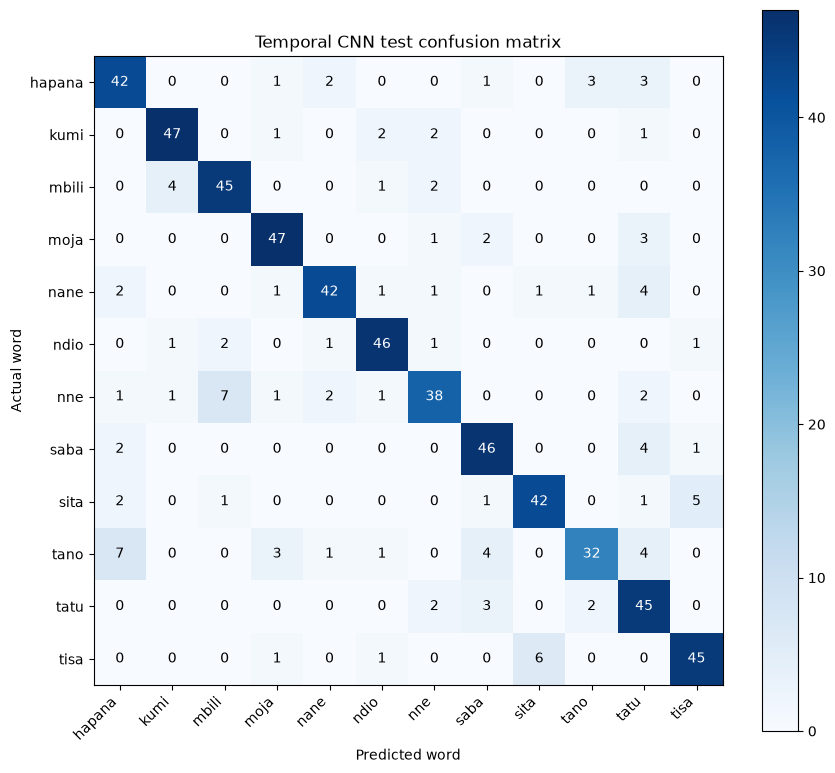

Total test errors: 113


,actual,predicted,count
29,nne,mbili,7
42,tano,hapana,7
53,tisa,sita,6
41,sita,tisa,5
9,mbili,kumi,4
21,nane,tatu,4
35,saba,tatu,4
47,tano,tatu,4
46,tano,saba,4
4,hapana,tatu,3


In [31]:
# Save the test confusion matrix figure.
fig, ax = plt.subplots(figsize=(9, 8))
matrix = test_confusion.to_numpy()
image = ax.imshow(matrix, cmap="Blues")
fig.colorbar(image, ax=ax)

ax.set_xticks(range(len(selected_classes)))
ax.set_yticks(range(len(selected_classes)))
ax.set_xticklabels(selected_classes, rotation=45, ha="right")
ax.set_yticklabels(selected_classes)
ax.set(
    xlabel="Predicted word",
    ylabel="Actual word",
    title="Temporal CNN test confusion matrix",
)

for row in range(len(selected_classes)):
    for col in range(len(selected_classes)):
        ax.text(
            col, row, str(matrix[row, col]),
            ha="center", va="center",
            color="white" if matrix[row, col] > matrix.max() / 2
            else "black",
        )

fig.tight_layout()
fig.savefig(selected_dir / "test_confusion_matrix.png", dpi=150)
plt.show()

# Rank incorrect class pairs.
pairs = [
    {
        "actual": actual,
        "predicted": predicted,
        "count": int(test_confusion.loc[actual, predicted]),
    }
    for actual in selected_classes
    for predicted in selected_classes
    if actual != predicted
    and test_confusion.loc[actual, predicted] > 0
]

test_pairs = pd.DataFrame(pairs).sort_values(
    "count", ascending=False
)
test_pairs.to_csv(
    selected_dir / "test_confusion_pairs.csv", index=False
)

print("Total test errors:", int((test_predictions != y_test).sum()))
display(test_pairs.head(10))

## CNN Results and Error Analysis

### Training Budget Comparison

| Maximum epochs | Selected epoch | Validation macro-F1 |
|---|---:|---:|
| 30 | 30 | 0.6986 |
| 60 | 59 | 0.8094 |

Increasing the training budget improved validation macro-F1 by
0.1108. The epoch-59 checkpoint was selected using validation
performance and fixed before CNN test evaluation.

### Final Test Results

The CNN correctly classified 517 of 630 recordings, making
113 errors. Test accuracy was 0.8206 and macro-F1 was 0.8197.

Kumi achieved the highest per-class F1 (0.8868). Tano had the
lowest F1 (0.7111), with 32 of 52 recordings correctly identified.

### Frequent Confusions

| Actual word | Predicted word | Errors |
|---|---|---:|
| nne | mbili | 7 |
| tano | hapana | 7 |
| tisa | sita | 6 |
| sita | tisa | 5 |
| mbili | kumi | 4 |
| nane | tatu | 4 |
| saba | tatu | 4 |
| tano | tatu | 4 |
| tano | saba | 4 |

The sita/tisa pair accounts for 11 errors across both directions.
Tatu's relatively low precision (0.6716) indicates that other
classes are frequently assigned this label.

These counts identify difficult distinctions but do not establish
their causes. Recording quality and pronunciation explanations
require inspection of the corresponding audio.

### Limitations

The CNN's convolutional receptive field covers nine frames.
Mean pooling summarizes local patterns but may lose information
about their ordering across the full recording.

The experiments used one seed, one shared split, and two training
budgets. Speaker-disjoint generalization was not established.

The shared test set had previously been inspected during the
archived Transformer experiment. CNN tuning and checkpoint
selection used validation data, but the test set was not entirely
unseen during the overall project.

Future work could investigate wider temporal context, alternative
pooling, and repeated experiments across multiple random seeds.

## Contribution Summary

Implemented and evaluated a temporal CNN with 25,548 parameters
for 12-class Swahili audio classification.

Used the shared split and training-fitted MFCC normalization.
Compared training budgets of 30 and 60 epochs using validation
macro-F1. Selected epoch 59 from the 60-epoch experiment.

Final test accuracy: 0.8206.
Final test macro-F1: 0.8197.
Correct predictions: 517 of 630.

Saved training histories, learning curves, classification reports,
and test confusion analysis.

The shared test set was previously inspected during an archived
Transformer experiment. CNN selection used validation results only.